# 04 — Merge & Feature Engineering

Merge all data sources into a single panel. Engineer features: shock indicator, AR lags, Trends features (slope, volatility, YoY, PCA), since-variables, fixed effects.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

I   = Path("../data/interim")
O   = Path("../data/processed")
FIG = Path("../output/figures")
O.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

In [2]:
# --- Load all parquets ---
laus        = pd.read_parquet(I / "laus_panel_with_shocks.parquet")
trends_long = pd.read_parquet(I / "google_trends_panel.parquet")
fred        = pd.read_parquet(I / "fred_macro.parquet")
claims      = pd.read_parquet(I / "state_initial_claims.parquet")
payrolls    = pd.read_parquet(I / "state_payrolls.parquet")

print("laus:        ", laus.shape,        laus.columns.tolist())
print("trends_long: ", trends_long.shape,  trends_long.columns.tolist())
print("fred:        ", fred.shape,         fred.columns.tolist())
print("claims:      ", claims.shape,       claims.columns.tolist())
print("payrolls:    ", payrolls.shape,     payrolls.columns.tolist())

laus:         (9180, 11) ['state_code', 'state_name', 'year', 'month', 'date', 'unemployment_rate', 'ma3', 'sahm_gap', 'shock_sahm_03', 'shock_sahm_05', 'shock_sahm_07']
trends_long:  (55080, 6) ['state_code', 'term', 'year', 'month_num', 'month', 'interest']
fred:         (180, 6) ['month', 'unrate_nat', 'icsa_mean', 'vix_mean', 'nasdaq_logret', 't10y2y_mean']
claims:       (9180, 3) ['state_code', 'month', 'init_claims_monthly']
payrolls:     (9180, 3) ['state_code', 'month', 'payrolls_thousands']


In [3]:
# --- Build base panel: rename columns to avoid collisions, then merge ---

# LAUS: rename int 'month' (1-12) to 'month_of_year'; use 'date' (timestamp) as merge key
laus = laus.rename(columns={"month": "month_of_year"})

# Pivot Google Trends long → wide: one column per term
trends_long = trends_long.rename(columns={"month": "date"})
terms     = sorted(trends_long["term"].unique())
term_slugs = {t: "gt_" + t.replace(" ", "_") for t in terms}

trends_wide = (
    trends_long
    .pivot_table(index=["state_code", "date"], columns="term", values="interest", aggfunc="mean")
    .reset_index()
)
trends_wide.columns = ["state_code", "date"] + [term_slugs[t] for t in terms]
print("trends_wide:", trends_wide.shape, trends_wide.columns.tolist())

# Rename 'month' → 'date' in the other frames
fred_m     = fred.rename(columns={"month": "date"})
claims_m   = claims.rename(columns={"month": "date"})
payrolls_m = payrolls.rename(columns={"month": "date"})

# Left-join everything onto LAUS
panel = laus.merge(trends_wide,  on=["state_code", "date"], how="left")
panel = panel.merge(fred_m,      on="date",                  how="left")
panel = panel.merge(claims_m,    on=["state_code", "date"],  how="left")
panel = panel.merge(payrolls_m,  on=["state_code", "date"],  how="left")

panel = panel.sort_values(["state_code", "date"]).reset_index(drop=True)
print("Panel after merge:", panel.shape)
print(panel.head(3).to_string())

trends_wide: (9180, 8) ['state_code', 'date', 'gt_file_for_unemployment', 'gt_jobs_hiring', 'gt_layoffs', 'gt_resume', 'gt_unemployment', 'gt_unemployment_benefits']
Panel after merge: (9180, 24)
  state_code state_name  year  month_of_year       date  unemployment_rate       ma3  sahm_gap  shock_sahm_03  shock_sahm_05  shock_sahm_07  gt_file_for_unemployment  gt_jobs_hiring  gt_layoffs  gt_resume  gt_unemployment  gt_unemployment_benefits  unrate_nat  icsa_mean   vix_mean  nasdaq_logret  t10y2y_mean  init_claims_monthly  payrolls_thousands
0         AK     Alaska  2010              1 2010-01-01                8.3       NaN       NaN              0              0              0                       0.0             0.0         0.0       91.0             30.0                      72.0         9.8   479800.0  20.643158            NaN     2.804211                16743               321.2
1         AK     Alaska  2010              2 2010-02-01                8.3       NaN       NaN        

## Feature Group A — Text features (Google Trends)

Z-score each term within-state (uses full panel mean/std — mild simplification; PCA must be fit **inside the rolling forecast loop** on training data only to prevent leakage). Then build slope, volatility, and YoY features. Google Trends is available at time *t* (no lag needed).

In [4]:
gt_cols = list(term_slugs.values())  # e.g. ['gt_file_for_unemployment', 'gt_jobs_hiring', ...]

feature_cols_A = []
for col in gt_cols:
    # Z-score within state
    panel[f"{col}_z"] = panel.groupby("state_code")[col].transform(
        lambda x: (x - x.mean()) / max(x.std(ddof=0), 1e-8)
    )
    # 1-month change of z-scored level
    panel[f"{col}_d1"] = panel.groupby("state_code")[f"{col}_z"].transform(
        lambda x: x.diff(1)
    )
    # 3-month rolling std (current + 2 prior months; no look-ahead)
    panel[f"{col}_std3"] = panel.groupby("state_code")[f"{col}_z"].transform(
        lambda x: x.rolling(3, min_periods=2).std()
    )
    # Year-over-year with additive smoothing (+1) to avoid division by zero on sparse terms
    panel[f"{col}_yoy"] = panel.groupby("state_code")[col].transform(
        lambda x: (x + 1) / (x.shift(12) + 1) - 1
    )
    feature_cols_A += [f"{col}_z", f"{col}_d1", f"{col}_std3", f"{col}_yoy"]

# Raw z-scored levels kept as PCA inputs (to be fit inside rolling loop)
pca_input_cols = [f"{col}_z" for col in gt_cols]
print(f"Group A features built: {len(feature_cols_A)}")
print(feature_cols_A[:8], "...")

Group A features built: 24
['gt_file_for_unemployment_z', 'gt_file_for_unemployment_d1', 'gt_file_for_unemployment_std3', 'gt_file_for_unemployment_yoy', 'gt_jobs_hiring_z', 'gt_jobs_hiring_d1', 'gt_jobs_hiring_std3', 'gt_jobs_hiring_yoy'] ...


## Feature Group B — Unemployment rate lags

Official UR (LAUS) is released with a ~1-month lag, so we apply `shift(1)` before any rolling operations to prevent look-ahead.

In [5]:
for lag in [1, 2, 3, 6, 12]:
    panel[f"ur_lag{lag}"] = panel.groupby("state_code")["unemployment_rate"].transform(
        lambda x, l=lag: x.shift(l)
    )

# 1-month and 3-month changes (both use lagged series → no look-ahead)
panel["ur_chg1"] = panel["ur_lag1"] - panel["ur_lag2"]
panel["ur_chg3"] = panel["ur_lag1"] - panel["ur_lag3"]

# 3-month rolling std of UR: shift(1) then rolling(3) → uses UR at t-1, t-2, t-3
panel["ur_std3"] = panel.groupby("state_code")["unemployment_rate"].transform(
    lambda x: x.shift(1).rolling(3, min_periods=2).std()
)

feature_cols_B = [f"ur_lag{l}" for l in [1, 2, 3, 6, 12]] + ["ur_chg1", "ur_chg3", "ur_std3"]
print(f"Group B features built: {len(feature_cols_B)}")
print(feature_cols_B)

Group B features built: 8
['ur_lag1', 'ur_lag2', 'ur_lag3', 'ur_lag6', 'ur_lag12', 'ur_chg1', 'ur_chg3', 'ur_std3']


## Feature Group C — Since-variables

Encode the "state of the cycle" for each state: time since the last Sahm shock, accumulated shocks in recent history, and the continuous Sahm gap. All based on prior months (no look-ahead).

In [6]:
def months_since_last_shock(s):
    """Months since the most recent shock_sahm_05==1 BEFORE the current month. Capped at 36."""
    result = np.full(len(s), 36.0)
    last_pos = None
    for i, v in enumerate(s.values):
        if last_pos is not None:
            result[i] = min(i - last_pos, 36)
        # update AFTER assigning so current month's shock counts for future rows only
        if v == 1:
            last_pos = i
    return pd.Series(result, index=s.index)

panel["months_since_last_sahm_shock"] = (
    panel.groupby("state_code")["shock_sahm_05"]
    .transform(months_since_last_shock)
)

# Cumulative shocks in prior 24 months: shift(1) excludes current month
panel["cumulative_sahm_shocks_24m"] = panel.groupby("state_code")["shock_sahm_05"].transform(
    lambda x: x.shift(1).rolling(24, min_periods=1).sum()
)

# Continuous Sahm gap, lagged by 1
panel["sahm_gap_lag1"] = panel.groupby("state_code")["sahm_gap"].transform(
    lambda x: x.shift(1)
)

feature_cols_C = ["months_since_last_sahm_shock", "cumulative_sahm_shocks_24m", "sahm_gap_lag1"]
print(f"Group C features built: {len(feature_cols_C)}")
print(panel[feature_cols_C].describe().round(3))

Group C features built: 3
       months_since_last_sahm_shock  cumulative_sahm_shocks_24m  sahm_gap_lag1
count                      9180.000                    9129.000       8415.000
mean                         30.504                       0.210          0.341
std                          10.349                       0.414          1.356
min                           1.000                       0.000         -0.800
25%                          31.000                       0.000         -0.067
50%                          36.000                       0.000         -0.000
75%                          36.000                       0.000          0.133
max                          36.000                       2.000         20.700


## Feature Group D — Macro lags (lag 1)

All official/external series are lagged by 1 month: FRED macro controls, log state initial claims, and state payrolls YoY change.

In [7]:
fred_cols = ["unrate_nat", "icsa_mean", "vix_mean", "nasdaq_logret", "t10y2y_mean"]

# FRED is national: same value for all states — shift within-state is equivalent to global shift
for col in fred_cols:
    panel[f"{col}_lag1"] = panel.groupby("state_code")[col].transform(
        lambda x, c=col: x.shift(1)
    )

# Log state initial claims, lagged 1
panel["log_claims"] = np.log(panel["init_claims_monthly"].replace(0, np.nan))
panel["log_claims_lag1"] = panel.groupby("state_code")["log_claims"].transform(
    lambda x: x.shift(1)
)

# Payrolls YoY % change, lagged 1  (payrolls at t / payrolls at t-12 - 1, then lag)
panel["payrolls_yoy"] = panel.groupby("state_code")["payrolls_thousands"].transform(
    lambda x: x / x.shift(12) - 1
)
panel["payrolls_yoy_lag1"] = panel.groupby("state_code")["payrolls_yoy"].transform(
    lambda x: x.shift(1)
)

feature_cols_D = [f"{c}_lag1" for c in fred_cols] + ["log_claims_lag1", "payrolls_yoy_lag1"]
print(f"Group D features built: {len(feature_cols_D)}")
print(feature_cols_D)

Group D features built: 7
['unrate_nat_lag1', 'icsa_mean_lag1', 'vix_mean_lag1', 'nasdaq_logret_lag1', 't10y2y_mean_lag1', 'log_claims_lag1', 'payrolls_yoy_lag1']


## Feature Group E — Fixed effects, final assembly, and save

In [8]:
feature_cols_E = ["state_code", "month_of_year"]  # state_code one-hot encoded inside training

target_cols = ["shock_sahm_03", "shock_sahm_05", "shock_sahm_07"]
id_cols     = ["state_code", "state_name", "date", "year", "month_of_year"]

all_feature_cols = feature_cols_A + feature_cols_B + feature_cols_C + feature_cols_D + feature_cols_E

# Deduplicate (state_code / month_of_year already in id_cols)
keep_cols = list(dict.fromkeys(id_cols + target_cols + all_feature_cols))

panel_out = panel[keep_cols].copy()

# Drop rows where any feature column is NaN
# (first ~12 months per state lost due to lag-12 and YoY transforms)
n_before = len(panel_out)
panel_out = panel_out.dropna(subset=[c for c in keep_cols if c not in id_cols + target_cols + ["state_name"]])
n_after = len(panel_out)

print(f"Rows before NaN drop: {n_before}")
print(f"Rows after  NaN drop: {n_after}  (dropped {n_before - n_after}, {100*(n_before-n_after)/n_before:.1f}%)")
print(f"Final panel shape:    {panel_out.shape}")

O.mkdir(parents=True, exist_ok=True)
panel_out.to_parquet(O / "panel_with_features.parquet", index=False)
print("\nSaved → data/processed/panel_with_features.parquet")

Rows before NaN drop: 9180
Rows after  NaN drop: 8415  (dropped 765, 8.3%)
Final panel shape:    (8415, 50)

Saved → data/processed/panel_with_features.parquet


In [9]:
# --- Feature list grouped by category ---
groups = {
    "A — Text features (Google Trends)": feature_cols_A,
    "B — Unemployment rate lags":        feature_cols_B,
    "C — Since-variables":               feature_cols_C,
    "D — Macro lags (lag 1)":            feature_cols_D,
    "E — Fixed effects":                 feature_cols_E,
}
total = 0
for name, cols in groups.items():
    print(f"\n{name}  ({len(cols)} features)")
    for c in cols:
        print(f"  {c}")
    total += len(cols)
print(f"\nTOTAL FEATURES: {total}")

# --- Shock counts after NaN drop ---
print("\n--- Shock counts after NaN drop ---")
for col in target_cols:
    n = int(panel_out[col].sum())
    r = panel_out[col].mean()
    print(f"  {col}: {n} shocks  ({100*r:.2f}% base rate)")


A — Text features (Google Trends)  (24 features)
  gt_file_for_unemployment_z
  gt_file_for_unemployment_d1
  gt_file_for_unemployment_std3
  gt_file_for_unemployment_yoy
  gt_jobs_hiring_z
  gt_jobs_hiring_d1
  gt_jobs_hiring_std3
  gt_jobs_hiring_yoy
  gt_layoffs_z
  gt_layoffs_d1
  gt_layoffs_std3
  gt_layoffs_yoy
  gt_resume_z
  gt_resume_d1
  gt_resume_std3
  gt_resume_yoy
  gt_unemployment_z
  gt_unemployment_d1
  gt_unemployment_std3
  gt_unemployment_yoy
  gt_unemployment_benefits_z
  gt_unemployment_benefits_d1
  gt_unemployment_benefits_std3
  gt_unemployment_benefits_yoy

B — Unemployment rate lags  (8 features)
  ur_lag1
  ur_lag2
  ur_lag3
  ur_lag6
  ur_lag12
  ur_chg1
  ur_chg3
  ur_std3

C — Since-variables  (3 features)
  months_since_last_sahm_shock
  cumulative_sahm_shocks_24m
  sahm_gap_lag1

D — Macro lags (lag 1)  (7 features)
  unrate_nat_lag1
  icsa_mean_lag1
  vix_mean_lag1
  nasdaq_logret_lag1
  t10y2y_mean_lag1
  log_claims_lag1
  payrolls_yoy_lag1

E — Fixe

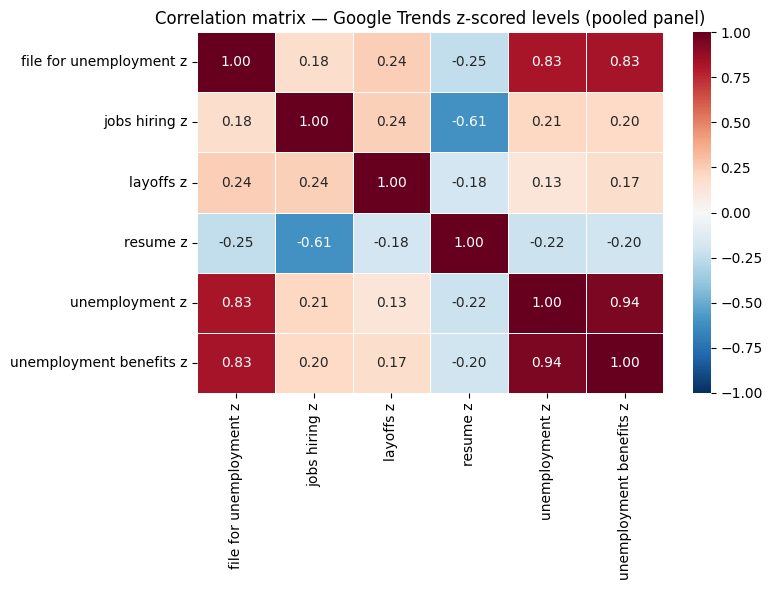

Saved → output/figures/04_text_features_corr.png


In [10]:
# --- Correlation heatmap of text z-scored levels ---
z_cols      = [f"{col}_z" for col in gt_cols]
z_labels    = [c.replace("gt_", "").replace("_", " ") for c in z_cols]
corr        = panel_out[z_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    xticklabels=z_labels, yticklabels=z_labels,
    linewidths=0.5, ax=ax
)
ax.set_title("Correlation matrix — Google Trends z-scored levels (pooled panel)")
plt.tight_layout()
fig.savefig(FIG / "04_text_features_corr.png", dpi=150)
plt.show()
print("Saved → output/figures/04_text_features_corr.png")